# 多元泰勒、Hessian 与牛顿法直觉 - 可视化

本 Notebook 生成三张图：
1. 椭圆等高线（曲率差异）
2. 梯度下降 vs 牛顿法路径对比
3. 收敛速度（损失曲线）对比

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/01_微积分/assets')

## 问题设置：二次函数

In [2]:
A = np.array([[8.0, 0.0], [0.0, 1.0]])  # 各向异性曲率
b = np.array([0.0, 0.0])

def J(w):
    return 0.5 * w.T @ A @ w - b.T @ w

def grad(w):
    return A @ w - b

def hessian(_w):
    return A

w_star = np.linalg.solve(A, b)
w_star

array([0., 0.])

## 图1：椭圆等高线

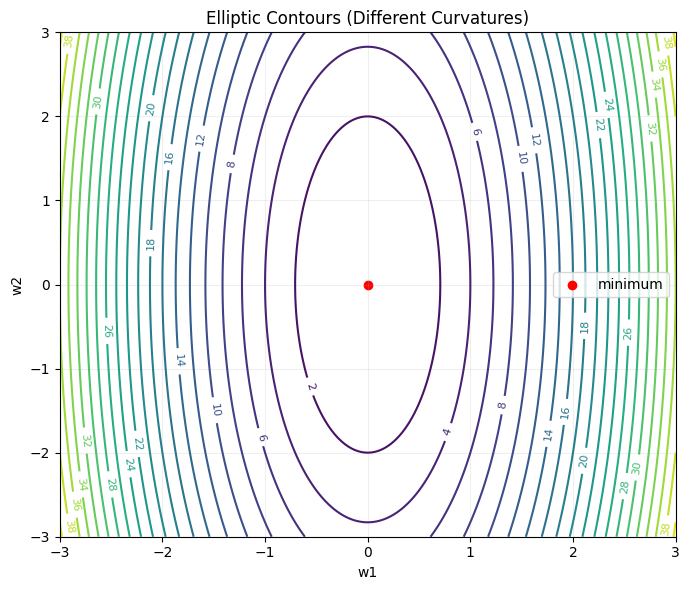

In [3]:
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)
Z = 0.5*(A[0,0]*X**2 + A[1,1]*Y**2)

plt.figure(figsize=(7,6))
cs = plt.contour(X, Y, Z, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([0], [0], c='red', label='minimum')
plt.title('Elliptic Contours (Different Curvatures)')
plt.xlabel('w1')
plt.ylabel('w2')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '10_hessian_contour.png', dpi=160)
plt.show()

## 图2：梯度下降 vs 牛顿法路径

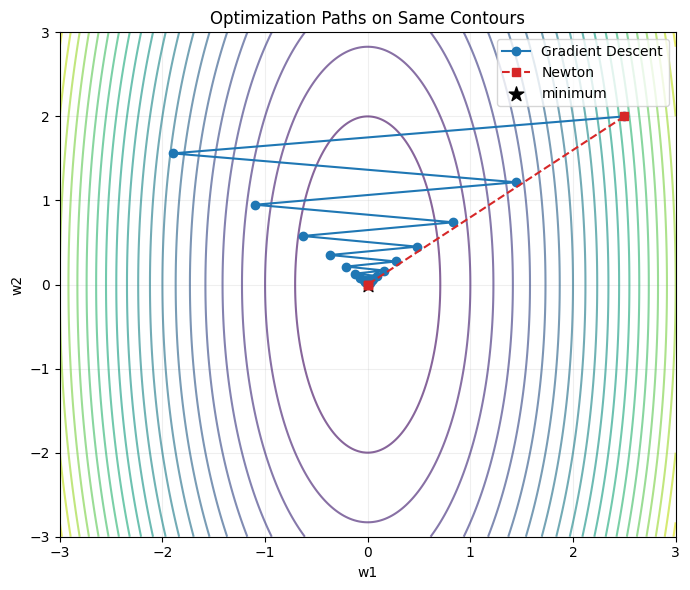

In [4]:
def run_gd(w0, lr=0.22, steps=20):
    ws = [w0.copy()]
    w = w0.copy()
    for _ in range(steps):
        w = w - lr * grad(w)
        ws.append(w.copy())
    return np.array(ws)

def run_newton(w0, steps=5):
    ws = [w0.copy()]
    w = w0.copy()
    for _ in range(steps):
        H = hessian(w)
        w = w - np.linalg.solve(H, grad(w))
        ws.append(w.copy())
    return np.array(ws)

w0 = np.array([2.5, 2.0])
path_gd = run_gd(w0, lr=0.22, steps=18)
path_newton = run_newton(w0, steps=3)

plt.figure(figsize=(7,6))
plt.contour(X, Y, Z, levels=20, alpha=0.65)
plt.plot(path_gd[:,0], path_gd[:,1], 'o-', label='Gradient Descent', color='tab:blue')
plt.plot(path_newton[:,0], path_newton[:,1], 's--', label='Newton', color='tab:red')
plt.scatter([0], [0], c='black', marker='*', s=120, label='minimum')
plt.title('Optimization Paths on Same Contours')
plt.xlabel('w1')
plt.ylabel('w2')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '11_gd_vs_newton_path.png', dpi=160)
plt.show()

## 图3：损失收敛速度对比

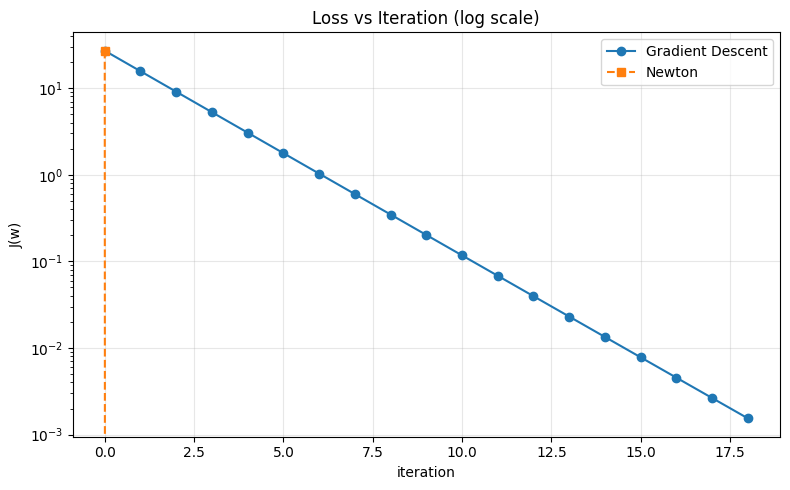

In [5]:
loss_gd = np.array([J(w) for w in path_gd])
loss_newton = np.array([J(w) for w in path_newton])

plt.figure(figsize=(8,5))
plt.plot(loss_gd, 'o-', label='Gradient Descent')
plt.plot(loss_newton, 's--', label='Newton')
plt.yscale('log')
plt.title('Loss vs Iteration (log scale)')
plt.xlabel('iteration')
plt.ylabel('J(w)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '12_gd_newton_loss_compare.png', dpi=160)
plt.show()

### 输出文件
- `assets/10_hessian_contour.png`
- `assets/11_gd_vs_newton_path.png`
- `assets/12_gd_newton_loss_compare.png`